# Customer Churn Prediction
**Dataset:** Telco Customer Churn (IBM Sample Dataset, ~7,000 customers)  
**Goal:** Predict whether a telecom customer will churn (leave the service), and identify key drivers of churn.

**Approach:**
- Exploratory Data Analysis (EDA)
- Preprocessing with pipelines (scaling, encoding, SMOTE for class imbalance)
- Multi-model comparison with 5-fold Stratified Cross-Validation
- Hyperparameter tuning with GridSearchCV
- Final model evaluation and feature importance

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier

print('All imports successful.')

All imports successful.


## 2. Load & Inspect Data

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f'Shape: {df.shape}')
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
pd.set_option('display.max_columns', None)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Observations from inspection:**
- `customerID` is an identifier with no predictive value — will be dropped.
- `TotalCharges` is stored as object (string) but should be numeric — contains whitespace for new customers with 0 tenure.
- `SeniorCitizen` is encoded as 0/1 integer, not object.

## 3. Data Cleaning

In [4]:
# Drop customerID — not a predictive feature
df = df.drop(columns=['customerID'])

# Fix TotalCharges: 11 rows have whitespace (new customers with tenure=0)
print(f'Rows with blank TotalCharges: {len(df[df["TotalCharges"] == " "])}')
df['TotalCharges'] = df['TotalCharges'].replace({' ': 0.0})
df['TotalCharges'] = df['TotalCharges'].astype(float)

# Encode target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print('Cleaning complete.')
df.info()

Rows with blank TotalCharges: 11
Cleaning complete.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   obj

## 4. Exploratory Data Analysis (EDA)

### 4.1 Class Distribution (Target)

Churn
0    5174
1    1869
Name: count, dtype: int64

Churn rate: 26.5%


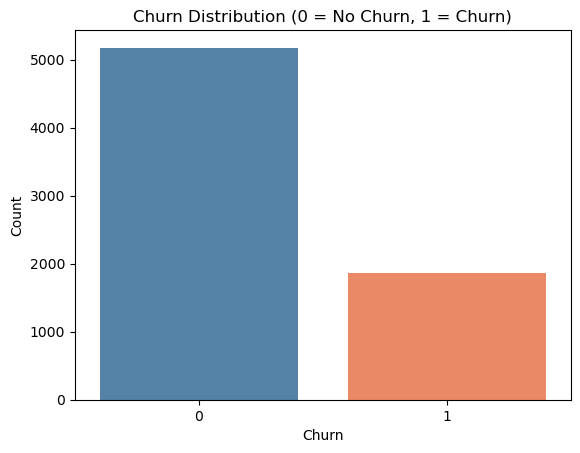

In [5]:
churn_counts = df['Churn'].value_counts()
print(churn_counts)
print(f'\nChurn rate: {churn_counts[1] / len(df) * 100:.1f}%')

sns.countplot(x='Churn', data=df, palette=['steelblue', 'coral'])
plt.title('Churn Distribution (0 = No Churn, 1 = Churn)')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

**Observation:** The dataset is imbalanced — only ~26% of customers churned. A naive model predicting 'No Churn' every time would get 74% accuracy but be useless. We will use **SMOTE** (Synthetic Minority Oversampling) inside the pipeline to address this, and track **Recall** and **F1** as primary metrics.

### 4.2 Numerical Features Distribution

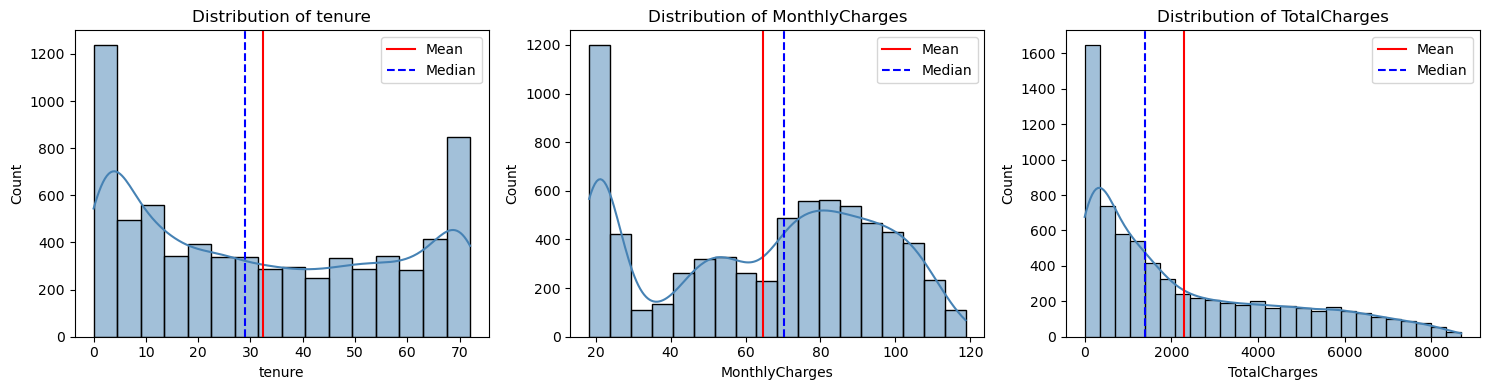

In [6]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.axvline(df[col].mean(),   color='red',  linestyle='-',  label='Mean')
    ax.axvline(df[col].median(), color='blue', linestyle='--', label='Median')
    ax.set_title(f'Distribution of {col}')
    ax.legend()
plt.tight_layout()
plt.show()

**Observation:** `tenure` is bimodal — many customers are either brand new or very long-term, with few in the middle. `MonthlyCharges` is roughly uniform-to-right-skewed. `TotalCharges` is right-skewed, which is expected as it is a product of tenure × monthly charges.

### 4.3 Churn vs Key Features

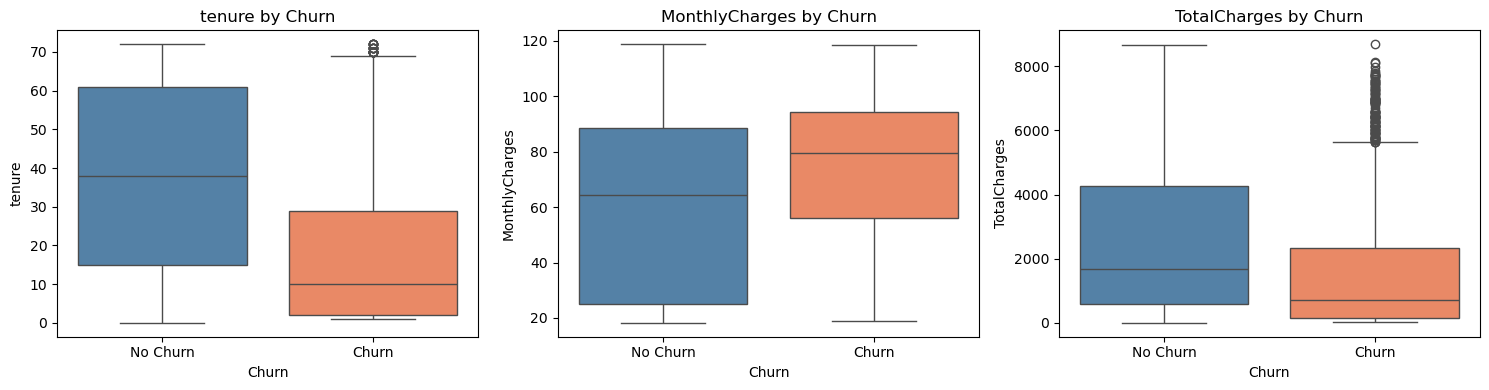

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(x='Churn', y=col, data=df, palette=['steelblue', 'coral'], ax=ax)
    ax.set_title(f'{col} by Churn')
    ax.set_xticklabels(['No Churn', 'Churn'])
plt.tight_layout()
plt.show()

**Observation:** Churned customers tend to have **shorter tenure**, **higher monthly charges**, and **lower total charges** — indicating they are relatively new customers on expensive plans. This gives a clear signal that pricing and early engagement are key churn drivers.

### 4.4 Categorical Features vs Churn

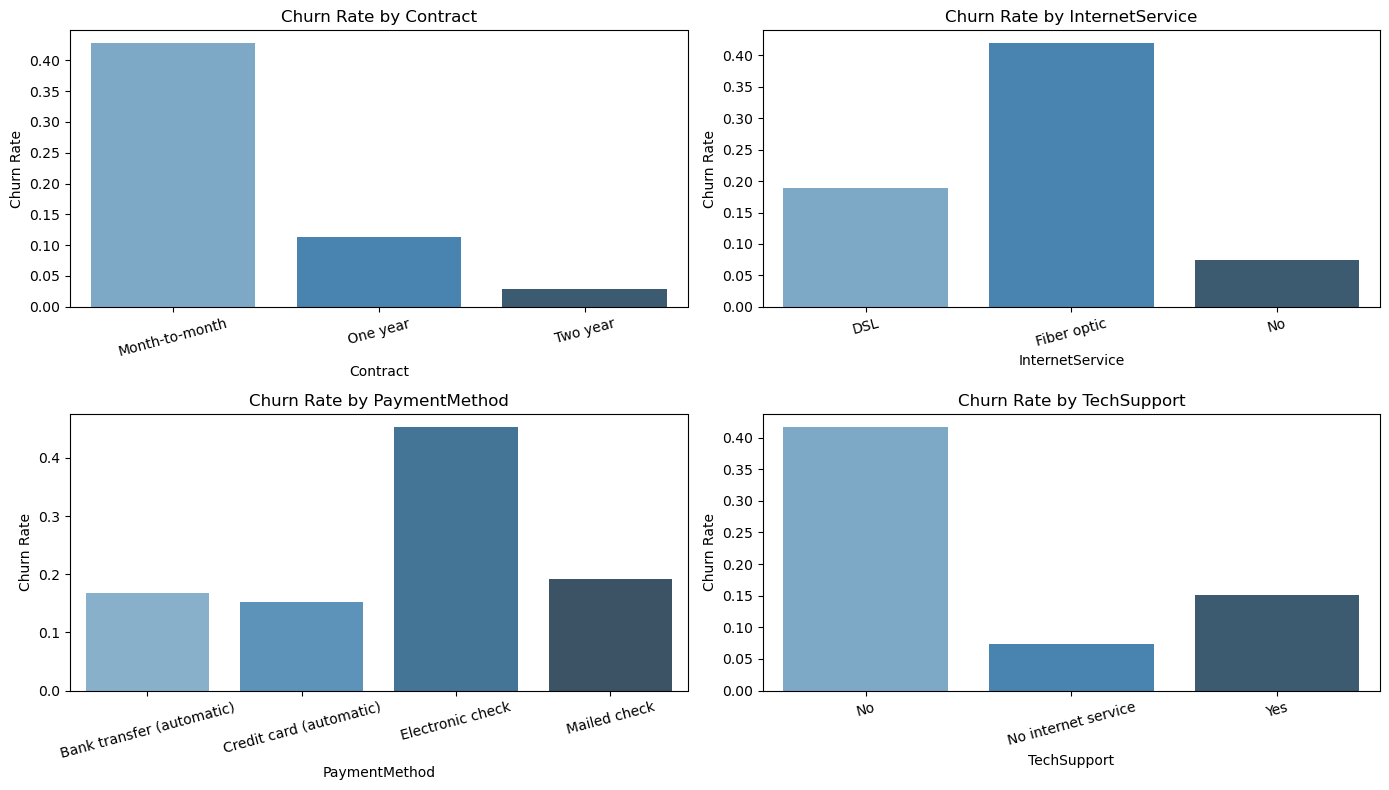

In [8]:
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.flatten(), cat_cols):
    churn_pct = df.groupby(col)['Churn'].mean().reset_index()
    sns.barplot(x=col, y='Churn', data=churn_pct, palette='Blues_d', ax=ax)
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Churn Rate')
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

**Observation:** Month-to-month contract customers churn at a much higher rate than 1 or 2-year contracts. Fiber optic internet users churn more than DSL users. Electronic check payment and lack of tech support are also associated with higher churn — all actionable business insights.

## 5. Preprocessing & Pipeline Setup

In [9]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f'Training samples: {len(X_train)}')
print(f'Test samples:     {len(X_test)}')

categorical_cols = X.select_dtypes(include='object').columns
numerical_cols   = X.select_dtypes(exclude='object').columns

print(f'\nNumerical features:   {list(numerical_cols)}')
print(f'Categorical features: {list(categorical_cols)}')

Training samples: 5634
Test samples:     1409

Numerical features:   ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [10]:
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, numerical_cols),
    ('cat', cat_pipe, categorical_cols)
])

print('Preprocessor defined.')

Preprocessor defined.


## 6. Multi-Model Comparison (5-Fold Stratified Cross-Validation)

We compare four models using cross-validation with SMOTE applied inside each fold (preventing data leakage). **Recall** is the primary metric — in churn prediction, missing a churner (false negative) is more costly than a false alarm.

In [11]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(random_state=42),
    'XGBoost':             XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'ANN (MLP)':           MLPClassifier(hidden_layer_sizes=(32, 16), activation='relu',
                                         solver='adam', max_iter=300, random_state=42)
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy':  'accuracy',
    'f1':        'f1',
    'recall':    'recall',
    'precision': 'precision',
    'roc_auc':   'roc_auc'
}

rows = []
for name, model in models.items():
    pipe = ImbPipeline(steps=[
        ('preprocessing', preprocessor),
        ('smote',         SMOTE(random_state=42)),
        ('model',         model)
    ])
    scores = cross_validate(pipe, X_train, y_train, scoring=scoring, cv=skf, n_jobs=-1)
    rows.append({
        'Model':      name,
        'CV Accuracy': round(scores['test_accuracy'].mean(), 4),
        'CV F1':       round(scores['test_f1'].mean(), 4),
        'CV Recall':   round(scores['test_recall'].mean(), 4),
        'CV Precision':round(scores['test_precision'].mean(), 4),
        'CV ROC-AUC':  round(scores['test_roc_auc'].mean(), 4),
    })

cv_results = pd.DataFrame(rows).sort_values('CV Recall', ascending=False).reset_index(drop=True)
print(cv_results.to_string(index=False))

              Model  CV Accuracy  CV F1  CV Recall  CV Precision  CV ROC-AUC
Logistic Regression       0.7556 0.6317     0.7906        0.5263      0.8446
          ANN (MLP)       0.7472 0.5803     0.6575        0.5199      0.7934
      Random Forest       0.7812 0.5807     0.5712        0.5912      0.8217
      Decision Tree       0.7315 0.5251     0.5592        0.4952      0.6770
            XGBoost       0.7801 0.5744     0.5592        0.5904      0.8222


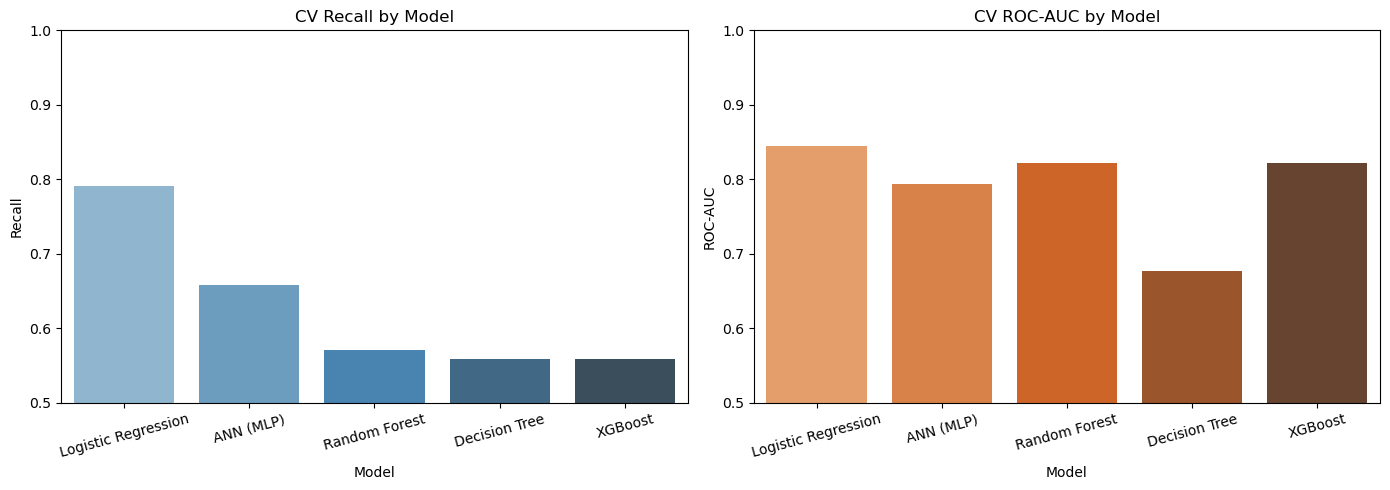

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x='Model', y='CV Recall', data=cv_results, palette='Blues_d', ax=axes[0])
axes[0].set_title('CV Recall by Model')
axes[0].set_ylabel('Recall')
axes[0].tick_params(axis='x', rotation=15)
axes[0].set_ylim(0.5, 1.0)

sns.barplot(x='Model', y='CV ROC-AUC', data=cv_results, palette='Oranges_d', ax=axes[1])
axes[1].set_title('CV ROC-AUC by Model')
axes[1].set_ylabel('ROC-AUC')
axes[1].tick_params(axis='x', rotation=15)
axes[1].set_ylim(0.5, 1.0)

plt.tight_layout()
plt.show()

**Observation:** Logistic Regression achieves the highest recall — meaning it catches the most actual churners. While tree-based models (Random Forest, XGBoost) achieve higher precision and AUC, for churn detection maximising recall is the business priority. We select **Logistic Regression** for tuning.

## 7. Hyperparameter Tuning — Logistic Regression (GridSearchCV)

In [13]:
lor_pipe = ImbPipeline(steps=[
    ('preprocessing', preprocessor),
    ('smote',         SMOTE(random_state=42)),
    ('model',         LogisticRegression(random_state=42))
])

param_grid = {
    'model__C':            [0.01, 0.1, 1, 10],
    'model__penalty':      ['l2'],
    'model__solver':       ['lbfgs', 'liblinear'],
    'model__class_weight': [None, 'balanced']
}

lor_grid = GridSearchCV(lor_pipe, param_grid, cv=skf, scoring='recall', n_jobs=-1, verbose=1)
lor_grid.fit(X_train, y_train)

print(f'Best CV Recall: {lor_grid.best_score_:.4f}')
print(f'Best Params:    {lor_grid.best_params_}')

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best CV Recall: 0.7906
Best Params:    {'model__C': 1, 'model__class_weight': None, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}


## 8. Final Model Evaluation on Test Set

In [14]:
# Retrain best model on full training set
best_params = lor_grid.best_params_

best_model = ImbPipeline(steps=[
    ('preprocessing', preprocessor),
    ('smote',         SMOTE(random_state=42)),
    ('model',         LogisticRegression(
        C=best_params['model__C'],
        penalty=best_params['model__penalty'],
        solver=best_params['model__solver'],
        class_weight=best_params['model__class_weight'],
        random_state=42
    ))
])

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

print('=== Test Set Results ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_pred):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

=== Test Set Results ===
Accuracy:  0.7367
Precision: 0.5025
Recall:    0.7995
F1 Score:  0.6171

              precision    recall  f1-score   support

    No Churn       0.91      0.71      0.80      1035
       Churn       0.50      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



### 8.1 Confusion Matrix

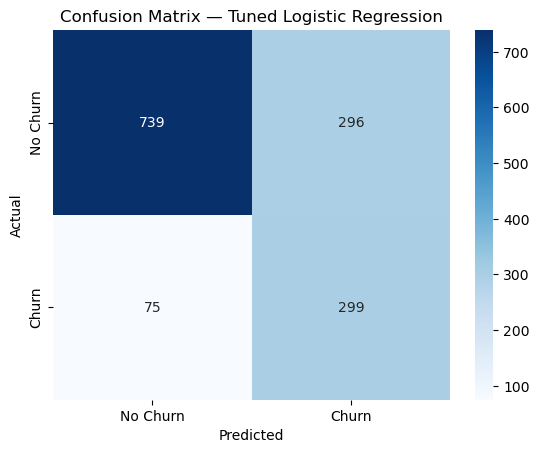

In [15]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix — Tuned Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### 8.2 ROC Curve

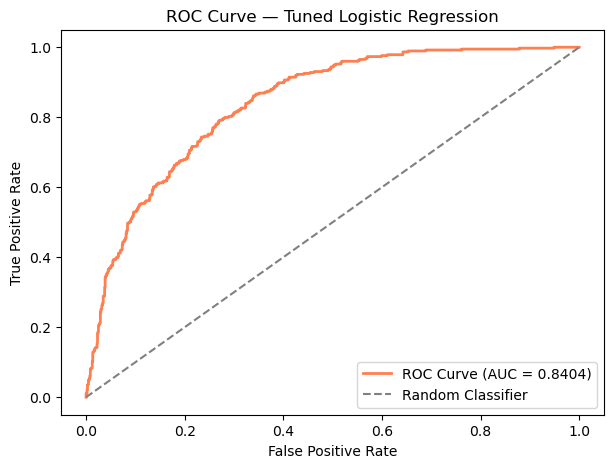

In [16]:
y_prob = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='coral', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Tuned Logistic Regression')
plt.legend()
plt.show()

## 9. Save Model

In [17]:
joblib.dump(best_model, 'churn_model.pkl')
print('Model saved as churn_model.pkl')
print(f'Input features: {list(X.columns)}')

Model saved as churn_model.pkl
Input features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


## 10. Conclusion

This project built an end-to-end customer churn prediction pipeline on the Telco dataset.

**Key findings from EDA:**
- Customers on month-to-month contracts, with fiber optic internet, and no tech support churn at significantly higher rates.
- Short-tenure customers with high monthly charges are the highest churn risk segment.

**Modelling results:**
- Five models were compared using 5-fold stratified cross-validation with SMOTE applied inside each fold to prevent data leakage.
- Logistic Regression achieved the best recall (~0.80), making it the best choice for a business that prioritises catching churners early.
- GridSearchCV further optimised the model's hyperparameters.

**Business recommendation:** Target retention campaigns at month-to-month contract customers in their first 12 months with monthly charges above the median.